Imports complete.
Total found: 349 PSG files and 350 Hypnogram files
Matched PSG/Hypnogram pairs: 349
Helper functions loaded.

Starting Feature Extraction for all datasets...

✅ Feature extraction complete!
Dataset shape: (50072, 11)
   rel_delta  rel_theta  rel_alpha  rel_beta         delta         theta  \
0   0.856922   0.118320   0.011683  0.013075  6.835205e-10  9.437714e-11   
1   0.550251   0.277394   0.125427  0.046927  4.109472e-11  2.071676e-11   
2   0.836204   0.134517   0.016439  0.012840  2.138113e-10  3.439504e-11   
3   0.848907   0.114855   0.026389  0.009849  4.500454e-10  6.088999e-11   
4   0.840530   0.116801   0.028816  0.013853  3.015060e-10  4.189765e-11   

          alpha          beta        label       subject  epoch  
0  9.319080e-12  1.042914e-11        Awake  SC4001E0-PSG      0  
1  9.367353e-12  3.504698e-12  Light Sleep  SC4001E0-PSG      1  
2  4.203340e-12  3.283194e-12  Light Sleep  SC4001E0-PSG      2  
3  1.399012e-11  5.221411e-12   Deep Sleep  

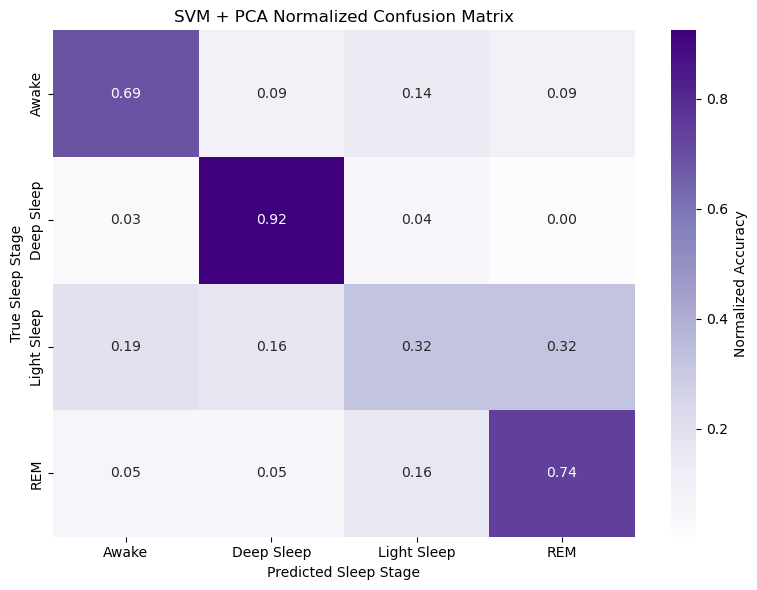


✅ SVM + PCA pipeline completed successfully!


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import mne
from scipy.signal import welch
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
mne.set_log_level("ERROR")

print("Imports complete.")

# -----------------------------------------------------------
# 1. LOAD MULTIPLE DATASET ROOTS
# -----------------------------------------------------------
DATA_ROOTS = [
    Path(r"C:\Users\Kiran Belagali\Downloads\sleep-edf-database-expanded-1.0.0"),
    Path(r"C:\Users\Kiran Belagali\Downloads\archive (3)\physiobank_database_sleep-edfx_sleep-cassette")
]

# -----------------------------------------------------------
# 2. FIND PSG/HYPNOGRAM PAIRS ACROSS ALL ROOTS
# -----------------------------------------------------------
psg_files, hyp_files = [], []

for root in DATA_ROOTS:
    psg_files.extend(sorted(list(root.rglob("*-PSG.edf"))))
    hyp_files.extend(sorted(list(root.rglob("*-Hypnogram.edf"))))

print(f"Total found: {len(psg_files)} PSG files and {len(hyp_files)} Hypnogram files")

# -----------------------------------------------------------
# 3. FIXED PAIR MATCHING LOGIC
# -----------------------------------------------------------
pairs = []
for psg in psg_files:
    base = psg.name.split("-")[0][:6]
    match = [h for h in hyp_files if h.name.startswith(base)]
    if match:
        pairs.append((psg, match[0]))

print(f"Matched PSG/Hypnogram pairs: {len(pairs)}")
if len(pairs) == 0:
    raise FileNotFoundError("❌ No PSG/Hypnogram pairs found. Check DATA_ROOT paths.")

# -----------------------------------------------------------
# 4. FEATURE EXTRACTION HELPERS
# -----------------------------------------------------------
def bandpower(data, sf, band):
    fmin, fmax = band
    nperseg = min(sf * 4, len(data))
    freqs, psd = welch(data, sf, nperseg=nperseg, window="hann")
    idx = np.logical_and(freqs >= fmin, freqs <= fmax)
    if not np.any(idx):
        return 0.0
    return np.trapz(psd[idx], freqs[idx])

BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
}

ORIG_LABEL_MAP = {1: "Awake", 2: "N1", 3: "N2", 4: "N3", 5: "REM"}
CONSOLIDATED = {
    "Awake": "Awake",
    "N1": "Light Sleep",
    "N2": "Light Sleep",
    "N3": "Deep Sleep",
    "REM": "REM",
}

print("Helper functions loaded.")

# -----------------------------------------------------------
# 5. FEATURE EXTRACTION LOOP
# -----------------------------------------------------------
all_features = []

print("\nStarting Feature Extraction for all datasets...")

for psg_path, hyp_path in pairs:
    try:
        raw = mne.io.read_raw_edf(str(psg_path), preload=True, verbose=False)
        ann = mne.read_annotations(str(hyp_path))
        raw.set_annotations(ann)

        # Pick primary EEG channel
        eeg_channels = mne.pick_types(raw.info, eeg=True)
        if len(eeg_channels) > 0:
            primary_channel = None
            for ch_name in ['EEG Fpz-Cz', 'EEG C3-A2', 'EEG C4-A1']:
                if ch_name in raw.ch_names:
                    primary_channel = ch_name
                    break
            if primary_channel is None:
                primary_channel = raw.ch_names[eeg_channels[0]]
            raw.pick_channels([primary_channel])
        else:
            continue

        # Filter EEG signal
        raw.filter(0.3, 35.0, fir_design="firwin", verbose=False)

        # Map annotations to standard events
        events, event_id = mne.events_from_annotations(
            raw,
            event_id={
                "Sleep stage W": 1, "Sleep stage 1": 2, "Sleep stage 2": 3,
                "Sleep stage 3": 4, "Sleep stage 4": 4, "Sleep stage R": 5,
                "Sleep stage ?": -1
            },
            verbose=False
        )
        valid_events = events[events[:, -1] != -1]
        valid_event_id = {k:v for k,v in event_id.items() if v != -1 and k.startswith("Sleep stage")}
        if len(valid_events) == 0:
            continue

        epochs = mne.Epochs(
            raw,
            events=valid_events,
            event_id=valid_event_id,
            tmin=0,
            tmax=30,
            baseline=None,
            preload=True,
            verbose=False,
        )

        data = epochs.get_data(copy=False)[:, 0, :]
        event_labels = epochs.events[:, -1]
        sfreq = raw.info["sfreq"]

        for i in range(len(data)):
            sample = data[i]
            abs_feat = {band: bandpower(sample, sfreq, BANDS[band]) for band in BANDS}
            total_power = sum(abs_feat.values())
            feat = {f"rel_{band}": abs_feat[band]/total_power if total_power>0 else 0.0
                    for band in BANDS}
            feat.update(abs_feat)

            orig_label = ORIG_LABEL_MAP.get(event_labels[i], "Unknown")
            if orig_label == "Unknown":
                continue
            feat["label"] = CONSOLIDATED[orig_label]
            feat["subject"] = psg_path.stem
            feat["epoch"] = i
            all_features.append(feat)

    except Exception as e:
        print(f"Error processing {psg_path.name}: {e}")

# Create dataset
df = pd.DataFrame(all_features)
df = df[df["label"] != "Unknown"].reset_index(drop=True)
print("\n✅ Feature extraction complete!")
print("Dataset shape:", df.shape)
print(df.head())

df.to_csv("sleep_edf_features_combined.csv", index=False)
print("Saved extracted features → sleep_edf_features_combined.csv")

# -----------------------------------------------------------
# 6. TRAIN/TEST PREPARATION
# -----------------------------------------------------------
FEATURE_COLUMNS = [
    "delta", "theta", "alpha", "beta",
    "rel_delta", "rel_theta", "rel_alpha", "rel_beta"
]

X = df[FEATURE_COLUMNS].values
y = df["label"].values

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------------------------------------
# 7. PCA (DIMENSIONALITY REDUCTION)
# -----------------------------------------------------------
from sklearn.decomposition import PCA

pca = PCA(n_components=4, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("\nPCA Explained Variance Ratio:")
print(pca.explained_variance_ratio_)
print("Total Variance Explained:", np.sum(pca.explained_variance_ratio_))

# -----------------------------------------------------------
# 8. TRAIN / TEST SPLIT
# -----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain/Test shapes:", X_train.shape, X_test.shape)

# -----------------------------------------------------------
# 9. SVM + GRID SEARCH
# -----------------------------------------------------------
from sklearn.svm import SVC

print("\n🚀 Training SVM + PCA model...")

svm = SVC(kernel="rbf", class_weight="balanced")

param_grid = {
    "C": [1, 5, 10, 20],
    "gamma": ["scale", 0.1, 0.01, 0.001]
}

grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
best_svm = grid.best_estimator_

print("\n✨ Best SVM Parameters:")
print(grid.best_params_)

# -----------------------------------------------------------
# 10. EVALUATION
# -----------------------------------------------------------
y_pred = best_svm.predict(X_test)

acc = accuracy_score(y_test, y_pred) * 100
print(f"\n🎯 SVM + PCA Accuracy: {acc:.2f}%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# -----------------------------------------------------------
# 11. CONFUSION MATRIX
# -----------------------------------------------------------
cm = confusion_matrix(y_test, y_pred, labels=best_svm.classes_)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Purples",
    xticklabels=best_svm.classes_,
    yticklabels=best_svm.classes_,
    cbar_kws={"label": "Normalized Accuracy"}
)

plt.title("SVM + PCA Normalized Confusion Matrix")
plt.xlabel("Predicted Sleep Stage")
plt.ylabel("True Sleep Stage")
plt.tight_layout()
plt.show()

print("\n✅ SVM + PCA pipeline completed successfully!")






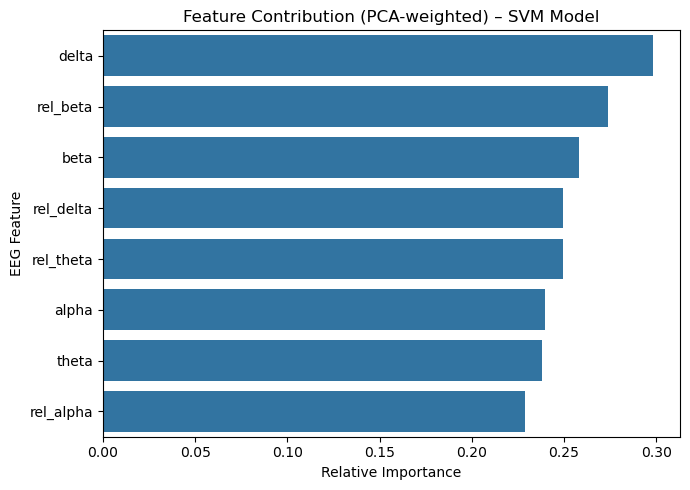

In [2]:
# PCA feature importance proxy (absolute loadings weighted by variance)
pca_importance = np.abs(pca.components_).T @ pca.explained_variance_ratio_

importance_df = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Importance": pca_importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(7,5))
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)
plt.title("Feature Contribution (PCA-weighted) – SVM Model")
plt.xlabel("Relative Importance")
plt.ylabel("EEG Feature")
plt.tight_layout()
plt.show()


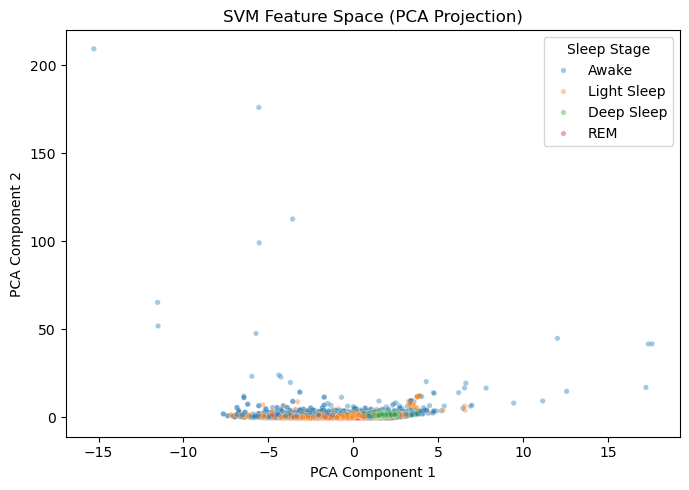

In [3]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y,
    alpha=0.4,
    s=15
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("SVM Feature Space (PCA Projection)")
plt.legend(title="Sleep Stage")
plt.tight_layout()
plt.show()


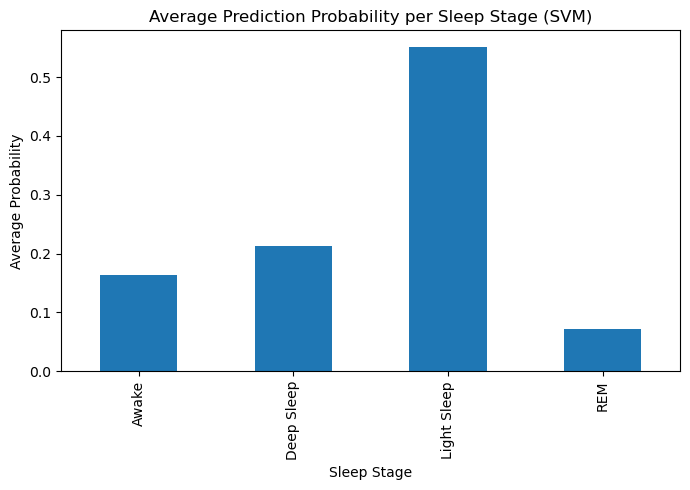

In [5]:
svm_prob = SVC(
    kernel="rbf",
    C=best_svm.C,
    gamma=best_svm.gamma,
    class_weight="balanced",
    probability=True
)
svm_prob.fit(X_train, y_train)

probs = svm_prob.predict_proba(X_test)
prob_df = pd.DataFrame(probs, columns=svm_prob.classes_)
avg_probs = prob_df.mean()

plt.figure(figsize=(7,5))
avg_probs.plot(kind="bar")
plt.ylabel("Average Probability")
plt.xlabel("Sleep Stage")
plt.title("Average Prediction Probability per Sleep Stage (SVM)")
plt.tight_layout()
plt.show()


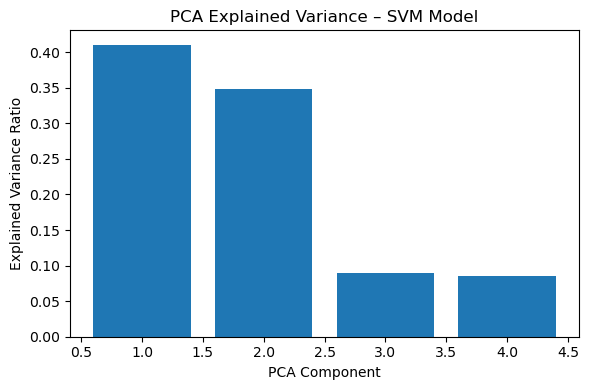

In [6]:
plt.figure(figsize=(6,4))
plt.bar(
    range(1, len(pca.explained_variance_ratio_)+1),
    pca.explained_variance_ratio_
)
plt.xlabel("PCA Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance – SVM Model")
plt.tight_layout()
plt.show()
